Resolved paths:
train: /kaggle/input/competitions/retroviral-challenge-predict/train.csv
test: /kaggle/input/competitions/retroviral-challenge-predict/test.csv
sample_submission: /kaggle/input/competitions/retroviral-challenge-predict/sample_submission.csv
feature_dictionary: /kaggle/input/competitions/retroviral-challenge-predict/feature_dictionary.csv
family_splits: /kaggle/input/competitions/retroviral-challenge-predict/family_splits.csv

Loaded shapes:
train: (57, 71)
test: (57, 69)
feature_dictionary: (66, 2)
family_splits: (7, 5)

Structures directory: /kaggle/input/competitions/retroviral-challenge-predict/structures
PDB train features: (57, 26)
PDB found rate: 1.0

Feature groups:
foldseek_core                             10 columns
   ['foldseek_best_TM', 'foldseek_best_LDDT', 'foldseek_best_fident', 'foldseek_TM_HIV1', 'foldseek_TM_MMLV', 'foldseek_TM_MMLVPE', 'foldseek_TM_Retron', 'foldseek_TM_LTRRetrotransposon', 'foldseek_TM_Group2Intron', 'foldseek_TM_Telomerase']
active_

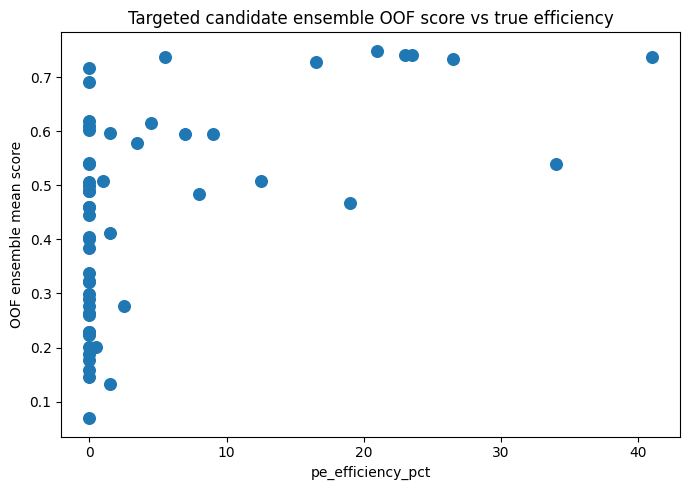

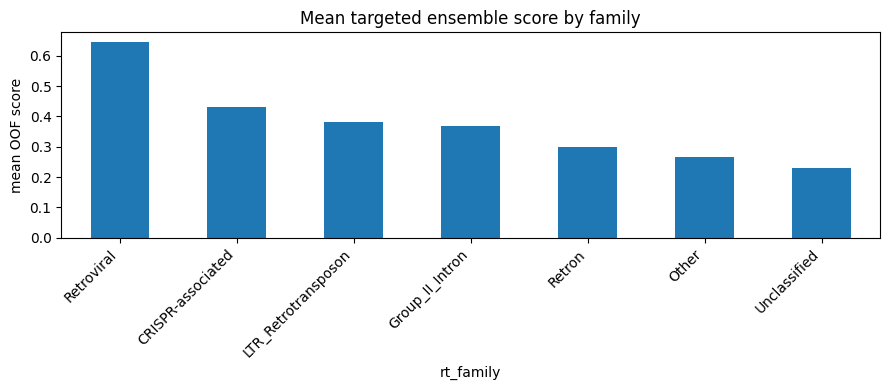


==================== FULL-DATA COEFFICIENT INSPECTION ====================
                                                 model              feature_group                                transformed_feature      coef  abs_coef
54              logreg_L1_C015_balanced__foldseek_core              foldseek_core                              num__foldseek_best_TM  0.627071  0.627071
56              logreg_L1_C015_balanced__foldseek_core              foldseek_core                          num__foldseek_best_fident  0.055984  0.055984
55              logreg_L1_C015_balanced__foldseek_core              foldseek_core                            num__foldseek_best_LDDT  0.000000  0.000000
57              logreg_L1_C015_balanced__foldseek_core              foldseek_core                              num__foldseek_TM_HIV1  0.000000  0.000000
58              logreg_L1_C015_balanced__foldseek_core              foldseek_core                              num__foldseek_TM_MMLV  0.000000  0.000000
59    

In [1]:
# ============================================================
# Targeted Investigation Notebook: FoldSeek + Mechanistic RT Features
# ============================================================
# Title:
#   Targeted Cross-Lineage Investigation for Prime Editing RT Activity
#
# Purpose:
#   This notebook is NOT the final competition submission pipeline.
#   It is a focused diagnostic notebook built from the previous investigation.
#
# Previous evidence:
#   1. FoldSeek-only models dominated LOFO validation.
#   2. Raw ESM embeddings clustered by family and did not improve LOFO.
#   3. Raw PDB descriptors were diagnostically useful but degraded performance
#      when added broadly.
#   4. Retron RTs were the dominant failure mode.
#   5. Two-stage activity x efficiency models did not outperform direct scoring.
#
# This notebook tests:
#   A. Whether selected mechanistic features improve FoldSeek-only models.
#   B. Whether Retron-specific failures can be reduced without memorizing family.
#   C. Whether models remain significant under label-shuffle and family-bootstrap tests.
#   D. Whether any feature set is stable enough for final submission.
#
# What to share back:
#   - targeted_results.csv
#   - targeted_per_family_results.csv
#   - targeted_family_bootstrap_stability.csv
#   - targeted_null_tests.csv
#   - targeted_oof_hard_cases.csv
#   - targeted_feature_coefficients.csv
#   - targeted_ablation_summary.csv
# ============================================================

import os
import re
import json
import math
import random
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from scipy.stats import spearmanr, kruskal
from scipy.spatial.distance import pdist, squareform

import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, RidgeClassifier, Ridge
from sklearn.metrics import average_precision_score, roc_auc_score, balanced_accuracy_score, matthews_corrcoef
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception:
    HAS_CATBOOST = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 240)


# ============================================================
# 0. Locate files and load data
# ============================================================
# Why:
#   Kaggle input paths vary. This makes the notebook portable.

INPUT_ROOTS = [Path("/kaggle/input"), Path("."), Path("/mnt/data")]


def find_file(filename):
    for root in INPUT_ROOTS:
        if not root.exists():
            continue
        matches = list(root.rglob(filename))
        if matches:
            return matches[0]
    raise FileNotFoundError(f"Could not find {filename}")

train_path = find_file("train.csv")
test_path = find_file("test.csv")
sub_path = find_file("sample_submission.csv")
feature_dict_path = find_file("feature_dictionary.csv")
family_splits_path = find_file("family_splits.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
feature_dict = pd.read_csv(feature_dict_path)
family_splits = pd.read_csv(family_splits_path)

print("Resolved paths:")
print("train:", train_path)
print("test:", test_path)
print("sample_submission:", sub_path)
print("feature_dictionary:", feature_dict_path)
print("family_splits:", family_splits_path)

print("\nLoaded shapes:")
print("train:", train.shape)
print("test:", test.shape)
print("feature_dictionary:", feature_dict.shape)
print("family_splits:", family_splits.shape)

OUT_DIR = Path("/kaggle/working/rt_targeted_investigation_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. Metric utilities
# ============================================================
# Why:
#   We report classification and ranking behavior separately.
#   The competition score combines activity recognition and ranking, so both matter.

logo = LeaveOneGroupOut()


def safe_ap(y_true, score):
    y_true = np.asarray(y_true)
    score = np.asarray(score)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, score)


def safe_auc(y_true, score):
    y_true = np.asarray(y_true)
    score = np.asarray(score)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, score)


def safe_spearman(y_true, score):
    y_true = np.asarray(y_true)
    score = np.asarray(score)
    if len(y_true) < 3 or len(np.unique(y_true)) < 2 or len(np.unique(score)) < 2:
        return np.nan
    return spearmanr(y_true, score).correlation


def metric_report(y_active, y_eff, score, model_name):
    y_active = np.asarray(y_active)
    y_eff = np.asarray(y_eff)
    score = np.asarray(score)
    return {
        "model": model_name,
        "AP_all": safe_ap(y_active, score),
        "ROC_AUC_all": safe_auc(y_active, score),
        "Spearman_eff_all": safe_spearman(y_eff, score),
        "Spearman_eff_active_only": safe_spearman(y_eff[y_active == 1], score[y_active == 1]),
        "BalancedAcc_at_median": balanced_accuracy_score(y_active, score >= np.median(score)),
        "MCC_at_median": matthews_corrcoef(y_active, score >= np.median(score)),
        "mean_score_active": float(np.mean(score[y_active == 1])),
        "mean_score_inactive": float(np.mean(score[y_active == 0])),
    }


# ============================================================
# 2. Corrected lightweight PDB parser
# ============================================================
# Why:
#   Previous structure diagnostics revealed that B-factors/pLDDT were likely
#   on a 0-1 scale, not 0-100. This parser normalizes confidence to 0-100.
#
# What this reveals:
#   Whether a tiny subset of local active-site structural descriptors improves
#   FoldSeek-only models without adding noisy global PDB features.

AA3_TO_1 = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
    "SEC": "U", "PYL": "O",
}


def locate_structures_dir():
    import zipfile
    for root in INPUT_ROOTS:
        if not root.exists():
            continue
        dirs = [d for d in root.rglob("structures") if d.is_dir()]
        if dirs:
            return dirs[0]
        zips = list(root.rglob("structures.zip"))
        if zips:
            out = Path("/kaggle/working/structures_unzipped")
            out.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(zips[0], "r") as zf:
                zf.extractall(out)
            nested = [d for d in out.rglob("structures") if d.is_dir()]
            if nested:
                return nested[0]
            return out
    return None

structures_dir = locate_structures_dir()
print("\nStructures directory:", structures_dir)


def parse_pdb_light(pdb_path):
    residues = {}
    with open(pdb_path, "r", errors="ignore") as f:
        for line in f:
            if not line.startswith("ATOM"):
                continue
            atom = line[12:16].strip()
            resn = line[17:20].strip()
            chain = line[21].strip()
            try:
                resi = int(line[22:26])
                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])
                b = float(line[60:66])
            except Exception:
                continue
            if atom.startswith("H"):
                continue
            key = (chain, resi, resn)
            residues.setdefault(key, {"atoms": {}, "bfactors": []})
            residues[key]["atoms"][atom] = np.array([x, y, z], dtype=float)
            residues[key]["bfactors"].append(b)

    ordered = []
    for key in sorted(residues.keys(), key=lambda k: (k[0], k[1])):
        resn = key[2]
        aa = AA3_TO_1.get(resn, "X")
        atoms = residues[key]["atoms"]
        if "CA" in atoms:
            ca = atoms["CA"]
        else:
            ca = np.mean(np.vstack(list(atoms.values())), axis=0)
        b = float(np.mean(residues[key]["bfactors"]))
        ordered.append({"key": key, "aa": aa, "ca": ca, "b": b})

    seq = "".join(r["aa"] for r in ordered)
    ca = np.vstack([r["ca"] for r in ordered]) if ordered else np.empty((0, 3))
    b = np.array([r["b"] for r in ordered], dtype=float) if ordered else np.array([])
    if len(b) and np.nanmax(b) <= 1.5:
        b = b * 100.0
    return seq, ca, b


def radius_of_gyration(coords):
    if len(coords) == 0:
        return np.nan
    center = coords.mean(axis=0)
    return float(np.sqrt(((coords - center) ** 2).sum(axis=1).mean()))


def contact_density(ca, cutoff):
    if len(ca) < 2:
        return np.nan, np.nan, np.nan
    D = squareform(pdist(ca))
    contacts = (D < cutoff) & (D > 0)
    deg = contacts.sum(axis=1)
    density = contacts.sum() / (len(ca) * (len(ca) - 1))
    return float(density), float(deg.mean()), float(deg.std())


def find_yxdd_like(seq):
    # Catalytic motif variants: Y/F - any residue - D/E - D
    m = re.search(r"[YF].[DE]D", seq)
    if m:
        return m.start(), m.group(0)
    return None, "MISSING"


def pdb_features(rt_name):
    out = {"rt_name": rt_name, "pdb_found": 0}
    if structures_dir is None:
        return out
    hits = []
    direct = structures_dir / f"{rt_name}.pdb"
    if direct.exists():
        hits = [direct]
    else:
        hits = list(structures_dir.rglob(f"{rt_name}.pdb"))
        if not hits:
            hits = list(structures_dir.rglob(f"*{rt_name}*.pdb"))
    if not hits:
        return out

    seq, ca, b = parse_pdb_light(hits[0])
    out["pdb_found"] = 1
    out["pdb_n_residues"] = len(ca)
    if len(ca) < 2:
        return out

    D = squareform(pdist(ca))
    rg = radius_of_gyration(ca)
    d8, mean_deg8, std_deg8 = contact_density(ca, 8.0)
    d10, mean_deg10, std_deg10 = contact_density(ca, 10.0)

    out.update({
        "pdb_rg_ca": rg,
        "pdb_rg_per_res": rg / max(len(ca), 1),
        "pdb_max_span_ca": float(np.max(D)),
        "pdb_span_per_res": float(np.max(D)) / max(len(ca), 1),
        "pdb_n_to_c_dist": float(np.linalg.norm(ca[0] - ca[-1])),
        "pdb_contact_density_8A": d8,
        "pdb_mean_degree_8A": mean_deg8,
        "pdb_std_degree_8A": std_deg8,
        "pdb_contact_density_10A": d10,
        "pdb_mean_degree_10A": mean_deg10,
        "pdb_std_degree_10A": std_deg10,
        "pdb_mean_confidence": float(np.mean(b)) if len(b) else np.nan,
        "pdb_low_conf_frac_lt70": float(np.mean(b < 70.0)) if len(b) else np.nan,
        "pdb_high_conf_frac_gt90": float(np.mean(b > 90.0)) if len(b) else np.nan,
    })

    idx, motif = find_yxdd_like(seq)
    out["pdb_yxdd_like_found"] = 1 if idx is not None else 0
    out["pdb_yxdd_like_motif"] = motif

    if idx is not None and idx + 3 < len(ca):
        motif_ca = ca[idx:idx + 4]
        motif_b = b[idx:idx + 4] if len(b) >= idx + 4 else np.array([])
        neigh8 = []
        neigh12 = []
        for j in range(idx, idx + 4):
            neigh8.append(np.sum((D[j] < 8.0) & (D[j] > 0)))
            neigh12.append(np.sum((D[j] < 12.0) & (D[j] > 0)))
        out.update({
            "pdb_yxdd_rg": radius_of_gyration(motif_ca),
            "pdb_yxdd_mean_confidence": float(np.mean(motif_b)) if len(motif_b) else np.nan,
            "pdb_yxdd_low_conf_frac_lt70": float(np.mean(motif_b < 70.0)) if len(motif_b) else np.nan,
            "pdb_yxdd_neighbors_8A": float(np.mean(neigh8)),
            "pdb_yxdd_neighbors_12A": float(np.mean(neigh12)),
            "pdb_yxdd_D1_D2_ca_dist": float(np.linalg.norm(ca[idx + 2] - ca[idx + 3])),
            "pdb_yxdd_Y_to_D2_ca_dist": float(np.linalg.norm(ca[idx] - ca[idx + 3])),
        })
    else:
        out.update({
            "pdb_yxdd_rg": np.nan,
            "pdb_yxdd_mean_confidence": np.nan,
            "pdb_yxdd_low_conf_frac_lt70": np.nan,
            "pdb_yxdd_neighbors_8A": np.nan,
            "pdb_yxdd_neighbors_12A": np.nan,
            "pdb_yxdd_D1_D2_ca_dist": np.nan,
            "pdb_yxdd_Y_to_D2_ca_dist": np.nan,
        })
    return out

if structures_dir is not None:
    pdb_train = pd.DataFrame([pdb_features(n) for n in train["rt_name"]])
    pdb_test = pd.DataFrame([pdb_features(n) for n in test["rt_name"]])
else:
    pdb_train = pd.DataFrame({"rt_name": train["rt_name"], "pdb_found": 0})
    pdb_test = pd.DataFrame({"rt_name": test["rt_name"], "pdb_found": 0})

print("PDB train features:", pdb_train.shape)
print("PDB found rate:", pdb_train["pdb_found"].mean())
pdb_train.to_csv(OUT_DIR / "targeted_pdb_features_train.csv", index=False)
pdb_test.to_csv(OUT_DIR / "targeted_pdb_features_test.csv", index=False)

train_aug = train.merge(pdb_train, on="rt_name", how="left")
test_aug = test.merge(pdb_test, on="rt_name", how="left")


# ============================================================
# 3. Targeted feature groups
# ============================================================
# Why:
#   We avoid all-feature dumping. Every feature group tests a specific hypothesis.
#
# Hypotheses:
#   foldseek_core:
#     Structure similarity to known RTs carries the main signal.
#   active_site_handcrafted:
#     Catalytic and local pocket features may rescue non-retroviral active RTs.
#   electrostatic_selected:
#     Local electrostatics near motif/subdomains may matter for substrate compatibility.
#   pdb_local_yxdd:
#     Local YXDD geometry may add family-independent mechanistic signal.
#   foldseek_plus_mechanistic:
#     Best candidate final direction if it beats FoldSeek-only under stability tests.

available_cols = set(train_aug.columns)

foldseek_core = [
    "foldseek_best_TM",
    "foldseek_best_LDDT",
    "foldseek_best_fident",
    "foldseek_TM_HIV1",
    "foldseek_TM_MMLV",
    "foldseek_TM_MMLVPE",
    "foldseek_TM_Retron",
    "foldseek_TM_LTRRetrotransposon",
    "foldseek_TM_Group2Intron",
    "foldseek_TM_Telomerase",
]

active_site_handcrafted = [
    "triad_found_bin",
    "D1_D2_dist",
    "D2_D3_dist",
    "triad_best_rmsd",
    "yxdd_hydrophobic_fraction",
    "yxdd_mean_hydrophobicity",
    "yxdd_std_hydrophobicity",
    "yxdd_y_is_strand",
    "yxdd_x_is_turn",
    "yxdd_d1_is_turn",
    "yxdd_d2_is_strand",
    "hairpin_pass",
    "hairpin_confidence",
    "yxdd_seq",
]

pocket_surface_selected = [
    "hydrophobic_per_res",
    "salt_per_res",
    "hbonds_per_res",
    "pocket_hydrophobic_per_res",
    "pocket_hbonds_per_res",
    "sasa_per_res",
    "apolar_ratio",
    "mean_rsasa",
    "pocket_mean_rsasa",
    "nterm_avg_sasa",
]

electrostatic_selected = [
    "overall_mean_pot",
    "fingers_mean_pot",
    "motif12_mean_pot",
    "lpqg_sp_3A_mean_pot",
    "yxdd_5A_mean_pot",
    "palm_mean_pot",
    "thumb_mean_pot",
    "connection_mean_pot",
]

sequence_simple_selected = [
    "protein_length_aa",
    "perplexity",
    "log_likelihood",
    "instability_index",
    "gravy",
    "camsol",
    "net_charge",
    "helix_beta_ratio",
]

pdb_local_yxdd = [
    "pdb_yxdd_like_found",
    "pdb_yxdd_like_motif",
    "pdb_yxdd_rg",
    "pdb_yxdd_mean_confidence",
    "pdb_yxdd_low_conf_frac_lt70",
    "pdb_yxdd_neighbors_8A",
    "pdb_yxdd_neighbors_12A",
    "pdb_yxdd_D1_D2_ca_dist",
    "pdb_yxdd_Y_to_D2_ca_dist",
]

pdb_compactness_selected = [
    "pdb_rg_ca",
    "pdb_rg_per_res",
    "pdb_max_span_ca",
    "pdb_span_per_res",
    "pdb_n_to_c_dist",
    "pdb_contact_density_8A",
    "pdb_mean_degree_8A",
    "pdb_std_degree_8A",
    "pdb_contact_density_10A",
    "pdb_mean_degree_10A",
    "pdb_std_degree_10A",
]


def existing(cols):
    return [c for c in cols if c in available_cols]

feature_groups = {
    "foldseek_core": existing(foldseek_core),
    "active_site_handcrafted": existing(active_site_handcrafted),
    "pocket_surface_selected": existing(pocket_surface_selected),
    "electrostatic_selected": existing(electrostatic_selected),
    "sequence_simple_selected": existing(sequence_simple_selected),
    "pdb_local_yxdd": existing(pdb_local_yxdd),
    "pdb_compactness_selected": existing(pdb_compactness_selected),
}

feature_groups["foldseek_plus_active_site"] = sorted(set(feature_groups["foldseek_core"] + feature_groups["active_site_handcrafted"]))
feature_groups["foldseek_plus_electrostatic"] = sorted(set(feature_groups["foldseek_core"] + feature_groups["electrostatic_selected"]))
feature_groups["foldseek_plus_pocket_surface"] = sorted(set(feature_groups["foldseek_core"] + feature_groups["pocket_surface_selected"]))
feature_groups["foldseek_plus_pdb_yxdd"] = sorted(set(feature_groups["foldseek_core"] + feature_groups["pdb_local_yxdd"]))
feature_groups["foldseek_plus_selected_mechanistic"] = sorted(set(
    feature_groups["foldseek_core"]
    + feature_groups["active_site_handcrafted"]
    + feature_groups["electrostatic_selected"]
    + feature_groups["pocket_surface_selected"]
    + feature_groups["pdb_local_yxdd"]
))
feature_groups["mechanistic_no_foldseek"] = sorted(set(
    feature_groups["active_site_handcrafted"]
    + feature_groups["electrostatic_selected"]
    + feature_groups["pocket_surface_selected"]
    + feature_groups["pdb_local_yxdd"]
    + feature_groups["sequence_simple_selected"]
))

print("\nFeature groups:")
for name, cols in feature_groups.items():
    print(f"{name:40s} {len(cols):3d} columns")
    print("  ", cols)


# ============================================================
# 4. Feature association and confounding table for selected features
# ============================================================
# Why:
#   Before modeling, identify features that are target-associated and whether
#   they are mostly family-associated. The best final features should ideally
#   have useful target signal but not purely family signal.

selected_all = sorted(set(sum(feature_groups.values(), [])))
selected_num = [c for c in selected_all if c in train_aug.columns and pd.api.types.is_numeric_dtype(train_aug[c])]
selected_cat = [c for c in selected_all if c in train_aug.columns and c not in selected_num]

assoc_rows = []
for col in selected_num:
    x = train_aug[col]
    mask = x.notna()
    if mask.sum() < 5 or x[mask].nunique() <= 1:
        continue
    rho_a = safe_spearman(train_aug.loc[mask, "active"], x[mask])
    rho_e = safe_spearman(train_aug.loc[mask, "pe_efficiency_pct"], x[mask])
    vals_by_fam = []
    for fam, df in train_aug.groupby("rt_family"):
        vals = df[col].dropna().values
        if len(vals):
            vals_by_fam.append(vals)
    try:
        fam_stat, fam_p = kruskal(*vals_by_fam) if len(vals_by_fam) >= 2 else (np.nan, np.nan)
    except Exception:
        fam_stat, fam_p = np.nan, np.nan
    assoc_rows.append({
        "feature": col,
        "spearman_active": rho_a,
        "spearman_efficiency": rho_e,
        "abs_spearman_active": abs(rho_a) if pd.notna(rho_a) else np.nan,
        "abs_spearman_efficiency": abs(rho_e) if pd.notna(rho_e) else np.nan,
        "kruskal_family_stat": fam_stat,
        "kruskal_family_p": fam_p,
        "missing_rate": x.isna().mean(),
    })

selected_assoc = pd.DataFrame(assoc_rows).sort_values("abs_spearman_active", ascending=False)
print("\nSelected feature association/confounding table:")
print(selected_assoc.head(80))
selected_assoc.to_csv(OUT_DIR / "targeted_feature_association_confounding.csv", index=False)


# ============================================================
# 5. Preprocessor and model utilities
# ============================================================
# Why:
#   All imputation/scaling/one-hot encoding must be fitted inside each LOFO fold.
#   This prevents leakage from validation family into training transformations.

try:
    OHE = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    OHE = OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(cols):
    num = [c for c in cols if c in train_aug.columns and pd.api.types.is_numeric_dtype(train_aug[c])]
    cat = [c for c in cols if c in train_aug.columns and c not in num]
    transformers = []
    if num:
        transformers.append((
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                ("scaler", RobustScaler()),
            ]),
            num,
        ))
    if cat:
        transformers.append((
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
                ("onehot", OHE),
            ]),
            cat,
        ))
    return ColumnTransformer(transformers=transformers, remainder="drop")


def score_from_model(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        raw = model.decision_function(X)
        raw = np.asarray(raw)
        return 1.0 / (1.0 + np.exp(-raw))
    pred = model.predict(X)
    return np.asarray(pred, dtype=float)


def lofo_evaluate(model, cols, model_name, train_df=None, y_override=None):
    if train_df is None:
        train_df = train_aug
    X = train_df[cols].copy()
    y_active = train_df["active"].values if y_override is None else np.asarray(y_override)
    y_eff = train_df["pe_efficiency_pct"].values
    groups = train_df["rt_family"].values
    oof = np.zeros(len(train_df), dtype=float)
    fold_rows = []

    for tr_idx, va_idx in logo.split(X, y_active, groups):
        heldout = groups[va_idx][0]
        pre = make_preprocessor(cols)
        X_tr = pre.fit_transform(X.iloc[tr_idx])
        X_va = pre.transform(X.iloc[va_idx])
        m = clone(model)
        try:
            m.fit(X_tr, y_active[tr_idx])
            score = score_from_model(m, X_va)
        except Exception:
            score = np.repeat(np.mean(y_active[tr_idx]), len(va_idx))
        oof[va_idx] = score
        fold_rows.append({
            "model": model_name,
            "heldout_family": heldout,
            "n_val": len(va_idx),
            "active_n_val": int(np.sum(y_active[va_idx])),
            "AP": safe_ap(y_active[va_idx], score),
            "ROC_AUC": safe_auc(y_active[va_idx], score),
            "Spearman_eff": safe_spearman(y_eff[va_idx], score),
            "mean_score_active": float(np.mean(score[y_active[va_idx] == 1])) if np.any(y_active[va_idx] == 1) else np.nan,
            "mean_score_inactive": float(np.mean(score[y_active[va_idx] == 0])) if np.any(y_active[va_idx] == 0) else np.nan,
        })

    report = metric_report(y_active, y_eff, oof, model_name)
    return oof, pd.DataFrame(fold_rows), report


# ============================================================
# 6. Targeted model zoo
# ============================================================
# Why these models:
#   Logistic L1/L2:
#     Primary candidate because FoldSeek-only worked best and small data favors
#     low-variance linear models.
#   Elastic-net logistic CV:
#     Tests whether sparse + ridge regularization helps selected mechanistic sets.
#   Linear SVM:
#     Tests margin-based linear ranking behavior.
#   Shallow ExtraTrees/RandomForest:
#     Tests limited nonlinearity without deep overfitting.
#   Tiny boosting models:
#     Included only as diagnostics; not trusted unless stable across families.

models = []
models.append((
    "logreg_L2_C025_balanced",
    LogisticRegression(penalty="l2", C=0.25, class_weight="balanced", solver="liblinear", random_state=RANDOM_STATE, max_iter=5000),
))
models.append((
    "logreg_L2_C01_balanced",
    LogisticRegression(penalty="l2", C=0.10, class_weight="balanced", solver="liblinear", random_state=RANDOM_STATE, max_iter=5000),
))
models.append((
    "logreg_L1_C015_balanced",
    LogisticRegression(penalty="l1", C=0.15, class_weight="balanced", solver="liblinear", random_state=RANDOM_STATE, max_iter=5000),
))
models.append((
    "logreg_L1_C005_balanced",
    LogisticRegression(penalty="l1", C=0.05, class_weight="balanced", solver="liblinear", random_state=RANDOM_STATE, max_iter=5000),
))
models.append((
    "linear_svm_C02_balanced",
    SVC(kernel="linear", C=0.2, class_weight="balanced", probability=True, random_state=RANDOM_STATE),
))
models.append((
    "extra_trees_depth2",
    ExtraTreesClassifier(n_estimators=500, max_depth=2, min_samples_leaf=4, class_weight="balanced", random_state=RANDOM_STATE),
))
models.append((
    "random_forest_depth2",
    RandomForestClassifier(n_estimators=500, max_depth=2, min_samples_leaf=4, class_weight="balanced", random_state=RANDOM_STATE),
))

if HAS_LGBM:
    models.append((
        "lgbm_tiny",
        LGBMClassifier(
            n_estimators=35,
            max_depth=2,
            num_leaves=4,
            learning_rate=0.03,
            min_child_samples=8,
            reg_alpha=2.0,
            reg_lambda=8.0,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            verbose=-1,
        ),
    ))
if HAS_CATBOOST:
    models.append((
        "catboost_tiny",
        CatBoostClassifier(
            iterations=70,
            depth=2,
            learning_rate=0.03,
            l2_leaf_reg=15,
            loss_function="Logloss",
            auto_class_weights="Balanced",
            verbose=False,
            random_seed=RANDOM_STATE,
        ),
    ))
if HAS_XGB:
    models.append((
        "xgb_tiny",
        XGBClassifier(
            n_estimators=35,
            max_depth=2,
            learning_rate=0.03,
            subsample=0.75,
            colsample_bytree=0.75,
            reg_alpha=2.0,
            reg_lambda=8.0,
            min_child_weight=4,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
        ),
    ))

print("\nModels:")
for n, _ in models:
    print(" -", n)


# ============================================================
# 7. Main targeted LOFO comparison
# ============================================================
# Why:
#   Directly compare FoldSeek-only against selected mechanistic additions.
#   A feature group is useful only if it improves AP/Spearman and does not
#   worsen the Retron fold or family-bootstrap stability.

all_reports = []
all_fold_reports = []
oof_predictions = {}

for fg_name, cols in feature_groups.items():
    if len(cols) == 0:
        continue
    print(f"\n--- Evaluating feature group: {fg_name} ({len(cols)} columns) ---")
    for model_name, model in models:
        full_name = f"{model_name}__{fg_name}"
        try:
            oof, fold_df, report = lofo_evaluate(model, cols, full_name)
            report["feature_group"] = fg_name
            report["base_model"] = model_name
            report["n_features_raw"] = len(cols)
            all_reports.append(report)
            fold_df["feature_group"] = fg_name
            fold_df["base_model"] = model_name
            all_fold_reports.append(fold_df)
            oof_predictions[full_name] = oof
            print(full_name, "AP=", round(report["AP_all"], 4), "Spearman=", round(report["Spearman_eff_all"], 4))
        except Exception as e:
            print("FAILED", full_name, "->", repr(e))

results = pd.DataFrame(all_reports).sort_values(["AP_all", "Spearman_eff_all"], ascending=False)
fold_results = pd.concat(all_fold_reports, ignore_index=True) if all_fold_reports else pd.DataFrame()

print("\n==================== TARGETED OVERALL RESULTS ====================")
print(results.head(100))

print("\n==================== TARGETED PER-FAMILY RESULTS FOR TOP MODELS ====================")
top_models = results.head(12)["model"].tolist()
print(fold_results[fold_results["model"].isin(top_models)].sort_values(["model", "heldout_family"]))

results.to_csv(OUT_DIR / "targeted_results.csv", index=False)
fold_results.to_csv(OUT_DIR / "targeted_per_family_results.csv", index=False)


# ============================================================
# 8. FoldSeek ablation and mechanistic add-on ablation
# ============================================================
# Why:
#   We need to know whether the model depends on one dominant FoldSeek feature,
#   and whether mechanistic additions help or simply add noise.
#
# What this reveals:
#   - Single-feature fragility.
#   - Which add-on groups improve FoldSeek-only.
#   - Whether a simpler final feature set is preferable.

print("\n==================== ABLATION TESTS ====================")

ablation_rows = []
primary_model = LogisticRegression(penalty="l2", C=0.25, class_weight="balanced", solver="liblinear", random_state=RANDOM_STATE, max_iter=5000)

# Baseline FoldSeek core
base_cols = feature_groups["foldseek_core"]
base_oof, _, base_report = lofo_evaluate(primary_model, base_cols, "ablation_baseline_foldseek_core")
base_ap = base_report["AP_all"]
base_sp = base_report["Spearman_eff_all"]
ablation_rows.append({"experiment": "baseline_foldseek_core", "n_features": len(base_cols), "AP": base_ap, "Spearman": base_sp})

# Drop-one FoldSeek features
for drop_col in base_cols:
    cols = [c for c in base_cols if c != drop_col]
    if not cols:
        continue
    oof, _, rep = lofo_evaluate(primary_model, cols, f"drop_{drop_col}")
    ablation_rows.append({
        "experiment": f"drop_{drop_col}",
        "n_features": len(cols),
        "AP": rep["AP_all"],
        "Spearman": rep["Spearman_eff_all"],
        "delta_AP_vs_foldseek": rep["AP_all"] - base_ap,
        "delta_Spearman_vs_foldseek": rep["Spearman_eff_all"] - base_sp,
    })

# Add-one mechanistic group to FoldSeek
for add_name in [
    "active_site_handcrafted",
    "pocket_surface_selected",
    "electrostatic_selected",
    "pdb_local_yxdd",
    "sequence_simple_selected",
    "pdb_compactness_selected",
]:
    cols = sorted(set(base_cols + feature_groups[add_name]))
    oof, _, rep = lofo_evaluate(primary_model, cols, f"foldseek_plus_{add_name}")
    ablation_rows.append({
        "experiment": f"foldseek_plus_{add_name}",
        "n_features": len(cols),
        "AP": rep["AP_all"],
        "Spearman": rep["Spearman_eff_all"],
        "delta_AP_vs_foldseek": rep["AP_all"] - base_ap,
        "delta_Spearman_vs_foldseek": rep["Spearman_eff_all"] - base_sp,
    })

ablation = pd.DataFrame(ablation_rows).sort_values(["AP", "Spearman"], ascending=False)
print(ablation)
ablation.to_csv(OUT_DIR / "targeted_ablation_summary.csv", index=False)


# ============================================================
# 9. Retron-focused diagnostics without training on family labels
# ============================================================
# Why:
#   Retron is the major failure mode. We cannot use rt_family as a feature,
#   but we can evaluate whether candidate models improve Retron held-out behavior.
#
# What this reveals:
#   Models that look good overall but fail on Retron are risky for Phase 2.

print("\n==================== RETRON DIAGNOSTICS ====================")

retron_rows = []
for _, row in results.iterrows():
    model_name = row["model"]
    sub = fold_results[(fold_results["model"] == model_name) & (fold_results["heldout_family"] == "Retron")]
    if len(sub):
        r = sub.iloc[0].to_dict()
        retron_rows.append({
            "model": model_name,
            "feature_group": row["feature_group"],
            "AP_all": row["AP_all"],
            "Spearman_all": row["Spearman_eff_all"],
            "Retron_AP": r["AP"],
            "Retron_ROC_AUC": r["ROC_AUC"],
            "Retron_Spearman": r["Spearman_eff"],
            "Retron_mean_active": r["mean_score_active"],
            "Retron_mean_inactive": r["mean_score_inactive"],
        })

retron_diag = pd.DataFrame(retron_rows).sort_values(["Retron_AP", "AP_all"], ascending=False)
print(retron_diag.head(50))
retron_diag.to_csv(OUT_DIR / "targeted_retron_diagnostics.csv", index=False)


# ============================================================
# 10. Family-bootstrap stability for top candidate models
# ============================================================
# Why:
#   With only seven families, one LOFO score is unstable.
#   This estimates score variation under family resampling.
#
# What this reveals:
#   Whether a model is robust or just benefits from a favorable family mix.

print("\n==================== FAMILY-BOOTSTRAP STABILITY ====================")

families = train_aug["rt_family"].unique().tolist()
y_active = train_aug["active"].values
y_eff = train_aug["pe_efficiency_pct"].values
groups = train_aug["rt_family"].values

selected_models_for_boot = results.head(min(25, len(results)))["model"].tolist()
selected_models_for_boot = [m for m in selected_models_for_boot if m in oof_predictions]

boot_rows = []
for b in range(1000):
    sampled_fams = np.random.choice(families, size=len(families), replace=True)
    idx = []
    for fam in sampled_fams:
        idx.extend(np.where(groups == fam)[0].tolist())
    idx = np.array(idx, dtype=int)
    for m in selected_models_for_boot:
        score = oof_predictions[m][idx]
        boot_rows.append({
            "bootstrap": b,
            "model": m,
            "AP": safe_ap(y_active[idx], score),
            "ROC_AUC": safe_auc(y_active[idx], score),
            "Spearman_eff": safe_spearman(y_eff[idx], score),
        })

boot = pd.DataFrame(boot_rows)
stability = boot.groupby("model").agg(
    AP_mean=("AP", "mean"),
    AP_std=("AP", "std"),
    AP_p05=("AP", lambda x: np.nanpercentile(x, 5)),
    AP_p10=("AP", lambda x: np.nanpercentile(x, 10)),
    AP_p50=("AP", lambda x: np.nanpercentile(x, 50)),
    AP_p90=("AP", lambda x: np.nanpercentile(x, 90)),
    Spearman_mean=("Spearman_eff", "mean"),
    Spearman_std=("Spearman_eff", "std"),
    Spearman_p10=("Spearman_eff", lambda x: np.nanpercentile(x, 10)),
).sort_values(["AP_mean", "Spearman_mean"], ascending=False)

print(stability)
stability.to_csv(OUT_DIR / "targeted_family_bootstrap_stability.csv")


# ============================================================
# 11. Null-label tests for candidate models
# ============================================================
# Why:
#   The previous no-FoldSeek baseline failed this test badly.
#   A credible candidate should beat shuffled-label performance.
#
# What this reveals:
#   Whether apparent LOFO performance is statistically meaningful at n=57.

print("\n==================== NULL-LABEL TESTS ====================")

null_candidates = results.head(min(8, len(results)))[["model", "feature_group", "base_model"]].copy()
# Always include FoldSeek baseline and best mechanistic-no-foldseek if present.
for must_have in [
    "logreg_L2_C025_balanced__foldseek_core",
    "logreg_L1_C015_balanced__foldseek_core",
    "logreg_L2_C025_balanced__foldseek_plus_selected_mechanistic",
    "logreg_L1_C015_balanced__foldseek_plus_selected_mechanistic",
]:
    if must_have in results["model"].values and must_have not in null_candidates["model"].values:
        r = results[results["model"] == must_have][["model", "feature_group", "base_model"]]
        null_candidates = pd.concat([null_candidates, r], ignore_index=True)

# Deduplicate
null_candidates = null_candidates.drop_duplicates("model")

null_rows = []
N_NULL = 300
for _, cand in null_candidates.iterrows():
    model_name = cand["model"]
    fg = cand["feature_group"]
    base_model_name = cand["base_model"]
    cols = feature_groups[fg]
    model = dict(models)[base_model_name]
    actual_score = oof_predictions[model_name]
    actual_ap = safe_ap(y_active, actual_score)
    actual_sp = safe_spearman(y_eff, actual_score)

    null_aps = []
    null_sps = []
    for i in range(N_NULL):
        y_shuf = np.random.permutation(y_active)
        try:
            oof_null, _, _ = lofo_evaluate(model, cols, f"null_{i}", y_override=y_shuf)
            null_aps.append(safe_ap(y_shuf, oof_null))
            null_sps.append(safe_spearman(y_eff, oof_null))
        except Exception:
            null_aps.append(np.nan)
            null_sps.append(np.nan)

    null_aps = np.array(null_aps, dtype=float)
    null_sps = np.array(null_sps, dtype=float)
    null_rows.append({
        "model": model_name,
        "feature_group": fg,
        "actual_AP": actual_ap,
        "null_AP_mean": np.nanmean(null_aps),
        "null_AP_p95": np.nanpercentile(null_aps, 95),
        "empirical_p_AP": np.nanmean(null_aps >= actual_ap),
        "actual_Spearman": actual_sp,
        "null_Spearman_mean": np.nanmean(null_sps),
        "null_Spearman_p95": np.nanpercentile(null_sps, 95),
        "empirical_p_Spearman": np.nanmean(null_sps >= actual_sp),
    })
    print(null_rows[-1])

null_tests = pd.DataFrame(null_rows).sort_values(["empirical_p_AP", "actual_AP"], ascending=[True, False])
print("\nNull-label test summary:")
print(null_tests)
null_tests.to_csv(OUT_DIR / "targeted_null_tests.csv", index=False)


# ============================================================
# 12. Candidate ensemble diagnostics
# ============================================================
# Why:
#   The final submission may use a small, stable ensemble.
#   This tests whether top models agree and where they fail.
#
# What this reveals:
#   - Consistent hard false negatives.
#   - Consistent false positives.
#   - High-disagreement examples where model family choice matters.

print("\n==================== CANDIDATE ENSEMBLE HARD-CASE ANALYSIS ====================")

# Choose candidate models using conservative filters if possible.
candidate_table = results.merge(
    stability.reset_index().rename(columns={"index": "model"}),
    on="model",
    how="left",
)
if len(null_tests):
    candidate_table = candidate_table.merge(null_tests[["model", "empirical_p_AP"]], on="model", how="left")
else:
    candidate_table["empirical_p_AP"] = np.nan

# Conservative rank: AP, Spearman, bootstrap lower bound, null p-value.
candidate_table["candidate_score"] = (
    candidate_table["AP_all"].fillna(0)
    + 0.5 * candidate_table["Spearman_eff_all"].fillna(0)
    + 0.5 * candidate_table["AP_p10"].fillna(0)
    - 0.2 * candidate_table["empirical_p_AP"].fillna(0.5)
)

candidate_table_sorted = candidate_table.sort_values("candidate_score", ascending=False)
print("\nCandidate table:")
print(candidate_table_sorted.head(30))
candidate_table_sorted.to_csv(OUT_DIR / "targeted_candidate_ranking.csv", index=False)

ensemble_models = [m for m in candidate_table_sorted.head(5)["model"].tolist() if m in oof_predictions]
pred_df = train_aug[["rt_name", "rt_family", "active", "pe_efficiency_pct"]].copy()
for m in ensemble_models:
    pred_df[m] = oof_predictions[m]
pred_df["candidate_ensemble_mean"] = pred_df[ensemble_models].mean(axis=1)
pred_df["candidate_ensemble_std"] = pred_df[ensemble_models].std(axis=1)
pred_df["candidate_ensemble_rank"] = pred_df["candidate_ensemble_mean"].rank(ascending=False)

print("\nEnsemble models:")
for m in ensemble_models:
    print(" -", m)

print("\nHard false negatives: active RTs predicted low")
print(pred_df[pred_df["active"] == 1].sort_values("candidate_ensemble_mean").head(20)[
    ["rt_name", "rt_family", "active", "pe_efficiency_pct", "candidate_ensemble_mean", "candidate_ensemble_std", "candidate_ensemble_rank"]
])

print("\nHard false positives: inactive RTs predicted high")
print(pred_df[pred_df["active"] == 0].sort_values("candidate_ensemble_mean", ascending=False).head(20)[
    ["rt_name", "rt_family", "active", "pe_efficiency_pct", "candidate_ensemble_mean", "candidate_ensemble_std", "candidate_ensemble_rank"]
])

print("\nHigh-disagreement RTs")
print(pred_df.sort_values("candidate_ensemble_std", ascending=False).head(25)[
    ["rt_name", "rt_family", "active", "pe_efficiency_pct", "candidate_ensemble_mean", "candidate_ensemble_std", "candidate_ensemble_rank"]
])

pred_df.to_csv(OUT_DIR / "targeted_oof_hard_cases.csv", index=False)

plt.figure(figsize=(7, 5))
plt.scatter(pred_df["pe_efficiency_pct"], pred_df["candidate_ensemble_mean"], s=70)
plt.title("Targeted candidate ensemble OOF score vs true efficiency")
plt.xlabel("pe_efficiency_pct")
plt.ylabel("OOF ensemble mean score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
pred_df.groupby("rt_family")["candidate_ensemble_mean"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Mean targeted ensemble score by family")
plt.ylabel("mean OOF score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ============================================================
# 13. Full-data coefficient inspection for candidate linear models
# ============================================================
# Why:
#   Coefficients are not causal, especially after full-data fitting.
#   But they help identify whether the model is dominated by expected structural
#   features or unstable/noisy add-ons.

print("\n==================== FULL-DATA COEFFICIENT INSPECTION ====================")

coef_rows = []
linear_candidate_models = [
    m for m in candidate_table_sorted.head(15)["model"].tolist()
    if m in oof_predictions and ("logreg" in m or "linear_svm" in m)
]

for model_name in linear_candidate_models:
    row = results[results["model"] == model_name].iloc[0]
    fg = row["feature_group"]
    base_model_name = row["base_model"]
    cols = feature_groups[fg]
    model = dict(models)[base_model_name]
    pre = make_preprocessor(cols)
    Xp = pre.fit_transform(train_aug[cols])
    m = clone(model)
    try:
        m.fit(Xp, train_aug["active"].values)
    except Exception as e:
        print("Skipping coefficient extraction for", model_name, repr(e))
        continue
    try:
        names = pre.get_feature_names_out().tolist()
    except Exception:
        names = [f"f{i}" for i in range(Xp.shape[1])]
    if hasattr(m, "coef_"):
        coefs = np.asarray(m.coef_).ravel()
    else:
        continue
    for name, coef in zip(names, coefs):
        coef_rows.append({
            "model": model_name,
            "feature_group": fg,
            "transformed_feature": name,
            "coef": coef,
            "abs_coef": abs(coef),
        })

coef_df = pd.DataFrame(coef_rows).sort_values(["model", "abs_coef"], ascending=[True, False])
print(coef_df.groupby("model").head(30))
coef_df.to_csv(OUT_DIR / "targeted_feature_coefficients.csv", index=False)


# ============================================================
# 14. Optional: generate diagnostic submission from best candidate
# ============================================================
# Why:
#   This is only a dry-run submission artifact, not a final decision.
#   It verifies that the selected pipeline can fit full train and score test.
#
# Important:
#   Since Phase 1 test has same RTs without labels, this file is mostly a
#   formatting check. We will choose final submission only after reviewing
#   this notebook's evidence.

print("\n==================== OPTIONAL DIAGNOSTIC SUBMISSION ====================")

best_row = candidate_table_sorted.iloc[0]
best_model_name = best_row["model"]
best_fg = best_row["feature_group"]
best_base = best_row["base_model"]
best_cols = feature_groups[best_fg]
best_model = dict(models)[best_base]

print("Best candidate by diagnostic ranking:", best_model_name)
print("Feature group:", best_fg)
print("Base model:", best_base)
print("Columns:", best_cols)

pre = make_preprocessor(best_cols)
X_full = pre.fit_transform(train_aug[best_cols])
X_test = pre.transform(test_aug[best_cols])
fit_model = clone(best_model)
fit_model.fit(X_full, train_aug["active"].values)
test_score = score_from_model(fit_model, X_test)

sub = pd.read_csv(sub_path)
sub["predicted_score"] = test_score
sub.to_csv(OUT_DIR / "targeted_diagnostic_submission.csv", index=False)
print(sub.head())


# ============================================================
# 15. Save manifest and reporting instructions
# ============================================================

manifest = {
    "output_dir": str(OUT_DIR),
    "best_candidate_model": best_model_name,
    "best_candidate_feature_group": best_fg,
    "best_candidate_base_model": best_base,
    "ensemble_models": ensemble_models,
    "n_models_evaluated": int(len(results)),
    "n_feature_groups": int(len(feature_groups)),
}
with open(OUT_DIR / "targeted_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print("\n==================== OUTPUT FILES ====================")
for p in sorted(OUT_DIR.glob("*")):
    print(" -", p.name)

print("""
\nPlease share these files or paste their top rows:

1. targeted_results.csv
2. targeted_per_family_results.csv
3. targeted_retron_diagnostics.csv
4. targeted_family_bootstrap_stability.csv
5. targeted_null_tests.csv
6. targeted_ablation_summary.csv
7. targeted_oof_hard_cases.csv
8. targeted_candidate_ranking.csv
9. targeted_feature_coefficients.csv
10. targeted_feature_association_confounding.csv

What we will decide from these:

A. Is FoldSeek-only still best after targeted mechanistic additions?
B. Does any add-on improve Retron without hurting overall LOFO?
C. Does the best model beat shuffled-label null tests convincingly?
D. Is the best model stable under family-bootstrap resampling?
E. Which features should be allowed in the final notebook?
F. Whether final submission should be single-model or small ensemble.
""")


In [2]:
import os
import zipfile
from IPython.display import FileLink

# Define the folder you want to zip
output_dir = '/kaggle/working'
zip_filename = 'output_folder.zip'

# Create the zip file
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(output_dir):
        for file in files:
            # Avoid zipping the zip file itself if it's in the same directory
            if file != zip_filename:
                zipf.write(os.path.join(root, file), 
                           os.path.relpath(os.path.join(root, file), output_dir))

# Create a download link
display(FileLink(zip_filename))


/kaggle/working/output_folder.zip